In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, precision_score, recall_score, f1_score

# Load the pre-processed dataset
df = pd.read_csv('/content/drive/MyDrive/processed_diabetes_dataset.csv')

# One-hot encode 'age_group' and 'smoking_history'
df = pd.get_dummies(df, columns=['age_group', 'smoking_history'], prefix=['age_group', 'smoking_history'])

# Identify features (X) and target (y)
# Using the original features plus the age-group and smoking_history one-hot encodings,
# ignoring the redundant "_std" scaled features for a clean model.
feature_cols = [
    'gender', 'age', 'hypertension', 'heart_disease',
    'smoking_history_0', 'smoking_history_1', 'smoking_history_2', 'smoking_history_3', 'smoking_history_4', 'smoking_history_5',
    'bmi', 'HbA1c_level', 'blood_glucose_level',
    'age_group_Adult', 'age_group_Middle-aged', 'age_group_Senior', 'age_group_Young'
]

# Use df which contains the one-hot encoded 'smoking_history' and 'age_group' columns
X = df[feature_cols]
y = df['diabetes'] # Target variable

# Data Splitting (Validation Method: Train-Test Split)
# Use 80% for training and 20% for testing, ensuring class distribution is maintained (stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (137427, 17), y_train shape: (137427,)
X_test shape: (34357, 17), y_test shape: (34357,)


Baseline XGBoost Model (Model Variety 1)


In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

# --- 1. DATA PREPARATION (FIXES THE NAMECALL ERROR) ---

# Load the pre-processed dataset
df = pd.read_csv("/content/drive/MyDrive/processed_diabetes_dataset.csv")

# One-hot encode 'age_group' and 'smoking_history' before selecting features
df = pd.get_dummies(df, columns=['age_group', 'smoking_history'], prefix=['age_group', 'smoking_history'])

# Identify features (X) and target (y)
feature_cols = [
    'gender', 'age', 'hypertension', 'heart_disease',
    'bmi', 'HbA1c_level', 'blood_glucose_level',
    'smoking_history_0', 'smoking_history_1', 'smoking_history_2', 'smoking_history_3', 'smoking_history_4', 'smoking_history_5',
    'age_group_Adult', 'age_group_Middle-aged', 'age_group_Senior', 'age_group_Young'
]


X = df[feature_cols]
y = df['diabetes'] # Target variable

# Data Splitting (Defines X_train, y_train, etc.)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 2. BASELINE MODEL CODE (Your Original Code + Metric Fix) ---

# Initialize a base XGBoost classifier
xgb_base = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Train the base model
# This line now works because X_train and y_train are defined above.
xgb_base.fit(X_train, y_train)

# Predict on the test set
y_pred_base = xgb_base.predict(X_test)
y_proba_base = xgb_base.predict_proba(X_test)[:, 1]

print("--- Baseline Model Metrics ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_proba_base):.4f}")

# Included Precision, Recall, and F1 Score (as previously suggested fix)
print(f"F1 Score: {f1_score(y_test, y_pred_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_base):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_base):.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [20:28:58] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Baseline Model Metrics ---
Accuracy: 0.9387
AUC: 0.9861
F1 Score: 0.9408
Precision: 0.9106
Recall: 0.9730


**Note:** Please ensure the previous cell (Data Splitting) has been run before executing this cell.

Hyperparameter Tuning using GridSearchCV

In [13]:
# Define a grid of hyperparameters to search
param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.05],
    'n_estimators': [100, 200],
    'subsample': [0.7, 0.9],
    'gamma': [0, 0.1]
}

# Initialize the XGBoost classifier for tuning
xgb_tune = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Initialize GridSearchCV (using F1 score as the primary optimization metric
# because it balances Precision and Recall, ideal for imbalanced classification)
grid_search = GridSearchCV(
    estimator=xgb_tune,
    param_grid=param_grid,
    scoring='f1', # Optimizing for F1 Score
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("\n--- GridSearchCV Results ---")
print(f"Best F1 Score: {best_score:.4f}")
print(f"Best Parameters: {best_params}")

Fitting 3 folds for each of 32 candidates, totalling 96 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [20:31:00] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- GridSearchCV Results ---
Best F1 Score: 0.9208
Best Parameters: {'gamma': 0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.7}


Optimized XGBoost Model (Model Variety 2)


In [14]:
# Initialize and train the optimized model (Model Variety 2)
xgb_optimized = XGBClassifier(
    **best_params,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_optimized.fit(X_train, y_train)

# Predict on the test set
y_pred_optimized = xgb_optimized.predict(X_test)
y_proba_optimized = xgb_optimized.predict_proba(X_test)[:, 1]

print("\n--- Optimized Model Training Complete ---")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [20:31:17] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Optimized Model Training Complete ---


FULL EVALUATION AND COMPARISON

In [15]:
def evaluate_model(y_test, y_pred, y_proba):
    """Calculates and prints all required evaluation metrics."""

    # Calculate required metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"AUC: {auc:.4f}")
    print("\nConfusion Matrix:")
    print(cm)

# Evaluate the optimized model
print("\n--- Optimized Model Evaluation (Model Variety 2) ---")
evaluate_model(y_test, y_pred_optimized, y_proba_optimized)

# Optional: Compare base model and optimized model
print("\n--- Comparison: Baseline vs. Optimized ---")
print(f"Baseline AUC: {roc_auc_score(y_test, y_proba_base):.4f}")
print(f"Optimized AUC: {roc_auc_score(y_test, y_proba_optimized):.4f}")
print(f"Baseline F1 Score: {f1_score(y_test, y_pred_base):.4f}")
print(f"Optimized F1 Score: {f1_score(y_test, y_pred_optimized):.4f}")


--- Optimized Model Evaluation (Model Variety 2) ---

Accuracy: 0.9197
F1 Score: 0.9221
Precision: 0.8951
Recall: 0.9508
AUC: 0.9798

Confusion Matrix:
[[15266  1913]
 [  846 16332]]

--- Comparison: Baseline vs. Optimized ---
Baseline AUC: 0.9861
Optimized AUC: 0.9798
Baseline F1 Score: 0.9408
Optimized F1 Score: 0.9221


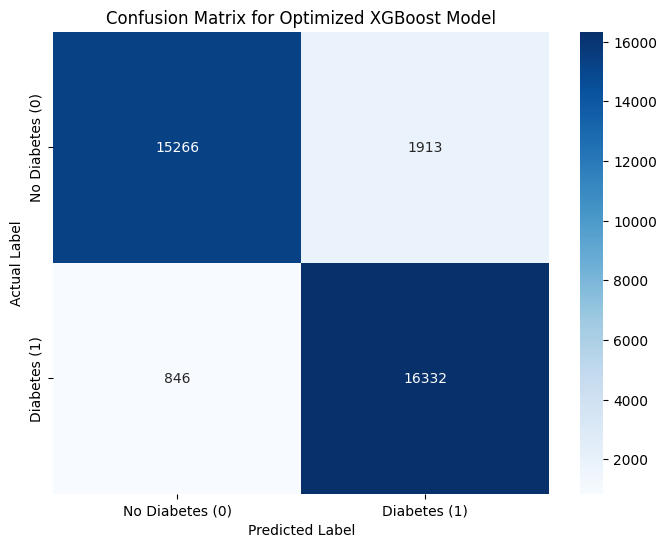

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred_optimized)

# Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Diabetes (0)', 'Diabetes (1)'],
    yticklabels=['No Diabetes (0)', 'Diabetes (1)']
)
plt.title('Confusion Matrix for Optimized XGBoost Model')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show() # Use plt.savefig("rf_confusion_matrix.png") for saving

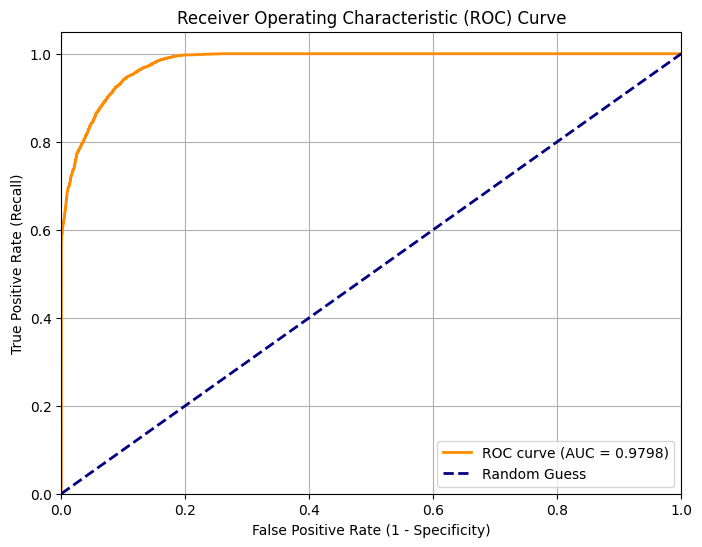

In [17]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve data points
fpr, tpr, thresholds = roc_curve(y_test, y_proba_optimized)
roc_auc = auc(fpr, tpr)

# Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
# Plot the baseline random guess line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show() # Use plt.savefig("rf_roc_curve.png") for saving